**Question 5, part c**

In [3]:
import numpy as np
import matplotlib.pyplot as plt

sigma^2 = 0.25
firing rate = 0.9642105263157895
fraction below 0 = 0.2626957894736842


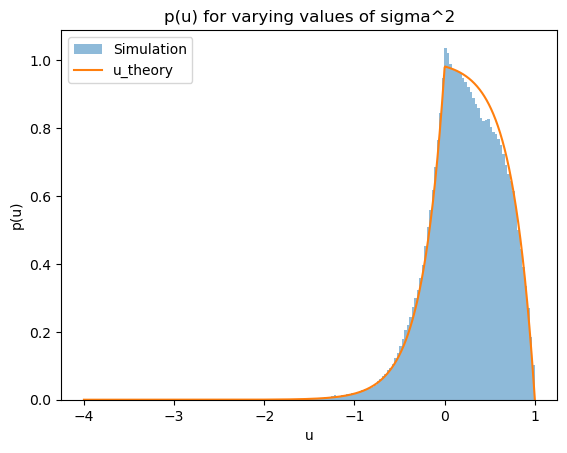

sigma^2 = 1
firing rate = 0.9557894736842105
fraction below 0 = 0.6275736842105263


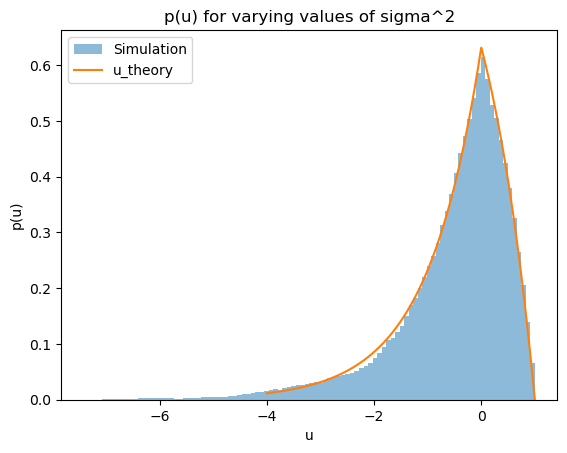

sigma^2 = 4
firing rate = 1.083157894736842
fraction below 0 = 0.8639426315789474


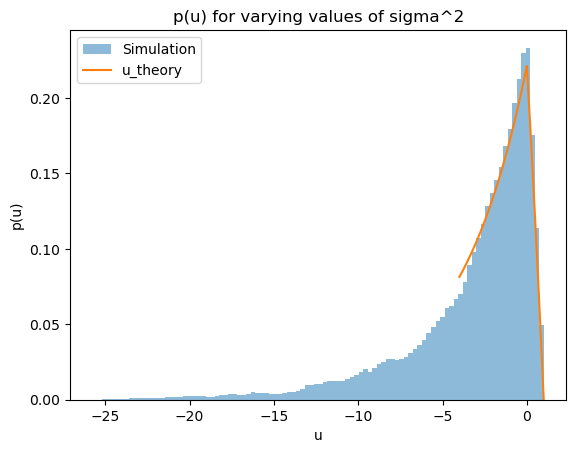

In [13]:
sig_vals = [0.25,1,4]

for s in sig_vals:
    steps = int(2000 / 0.001) #want 2000 time steps every 0.001 seconds
    transient = int(100/0.001) #the amount of time units ignored

    u = 0.0
    u_vals = []
    spike_ct = 0

    for n in range(steps):
        u += 1*0.001 + np.sqrt(2*s*0.001)*np.random.randn()
        #np.random.randn() generates numbers from a normal distribution

        if u >= 1:
            #testing for if u goes over the threshold and resetting it if it does
            if n >= transient:
                spike_ct += 1
            u = 0.0
            
        if n >= transient:
            u_vals.append(u)
                #these will be the values of u that the statistics get done on 

    u_vals = np.array(u_vals)
    #easier to work with
    frac_below = np.mean(u_vals < 0)
    firing_rate = spike_ct / (2000 - 100)

    print("sigma^2 =", s)
    print("firing rate =", firing_rate)
    print("fraction below 0 =", frac_below)


    u_theory = np.linspace(-4, 1, 1000)

    p = np.zeros_like(u_theory)
    #makes an array of zeros with the same shape as u_theory

    neg = u_theory < 0
    pos = (u_theory >= 0) & (u_theory <= 1)

    p[neg] = (1/1)* (1 - np.exp(-1*1/s))* np.exp(1*u_theory[neg]/s)
    p[pos] = (1/1)* (1 - np.exp(1*(u_theory[pos]-1)/s))
    #using the equations in part a

    plt.hist(u_vals,bins=100,density=True,alpha=0.5,label='Simulation')
    plt.plot(u_theory,p,label='u_theory')
    plt.xlabel('u')
    plt.ylabel('p(u)')
    plt.title('p(u) for varying values of sigma^2')
    plt.legend()
    plt.show()